In [1]:
!pip -q install -U importlib_resources protobuf tensorflow-datasets tensorflow-metadata

In [2]:
import gc
import time
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers, regularizers
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

tf.random.set_seed(42)
np.random.seed(42)

IMG_SIZE_SMALL = 160   # used for Tasks 1-5, 7 (many from-scratch training runs)
IMG_SIZE_FULL = 224    # used for Tasks 6, 8 (transfer learning + final model)
BATCH_SMALL = 16
BATCH_FULL = 32
NUM_CLASSES = 2  # Cat vs Dog

TRAIN_SUBSET = 1200   # images used per training run in Tasks 1-5, 7
VAL_SUBSET = 300       # images used per validation run in Tasks 1-5, 7

(ds_train, ds_val, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:70%]", "train[70%:85%]", "train[85%:]"],
    with_info=True,
    as_supervised=False,
)

def make_preprocess(img_size):
    def preprocess(example):
        image = tf.image.resize(example["image"], (img_size, img_size))
        image = tf.keras.applications.mobilenet_v2.preprocess_input(tf.cast(image, tf.float32))
        return image, example["species"]  # species: 0 = Cat, 1 = Dog
    return preprocess

def make_pipeline(ds, img_size, shuffle=False, augment=False, batch_size=BATCH_SMALL):
    ds = ds.map(make_preprocess(img_size), num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    if augment:
        aug = tf.keras.Sequential([layers.RandomFlip("horizontal"), layers.RandomRotation(0.05)])
        ds = ds.map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Light pipeline (160x160, batch 16, SUBSET of data) - Tasks 1-5, 7
train_ds_s = make_pipeline(ds_train.take(TRAIN_SUBSET), IMG_SIZE_SMALL, shuffle=True, augment=True, batch_size=BATCH_SMALL)
val_ds_s = make_pipeline(ds_val.take(VAL_SUBSET), IMG_SIZE_SMALL, batch_size=BATCH_SMALL)

# Full-resolution pipeline (224x224, batch 32) - Tasks 6, 8
train_ds_f = make_pipeline(ds_train, IMG_SIZE_FULL, shuffle=True, augment=True, batch_size=BATCH_FULL)
val_ds_f = make_pipeline(ds_val, IMG_SIZE_FULL, batch_size=BATCH_FULL)
test_ds_f = make_pipeline(ds_test, IMG_SIZE_FULL, batch_size=BATCH_FULL)

def build_model(initializer, img_size, dropout=0.0, l2_reg=0.0, use_bn=True, weights=None):
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None
    base = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3), include_top=False, weights=weights, pooling="avg"
    )
    x = base.output
    if use_bn:
        x = layers.BatchNormalization()(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax", kernel_initializer=initializer, kernel_regularizer=reg)(x)
    return base, models.Model(base.input, out)

def free_memory(*objs):
    """Delete given objects, clear the Keras backend graph, and force a GC pass.
    Call this after every model you finish training in a loop."""
    for o in objs:
        del o
    tf.keras.backend.clear_session()
    gc.collect()

print("Data pipelines ready:", ds_info.splits)
print(f"Tasks 1-5, 7 use a {TRAIN_SUBSET}-train/{VAL_SUBSET}-val subset at {IMG_SIZE_SMALL}x{IMG_SIZE_SMALL}")
print(f"Tasks 6, 8 use the full dataset at {IMG_SIZE_FULL}x{IMG_SIZE_FULL}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.C6RE9U_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.C6RE9U_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Data pipelines ready: {'train': <SplitInfo num_examples=3680, num_shards=4>, 'test': <SplitInfo num_examples=3669, num_shards=4>}
Tasks 1-5, 7 use a 1200-train/300-val subset at 160x160
Tasks 6, 8 use the full dataset at 224x224


Task 4

Training with SGD
Epoch 1/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 62s 295ms/step - accuracy: 0.5267 - loss: 1.4052 - val_accuracy: 0.6933 - val_loss: 0.6322
Epoch 2/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.5883 - loss: 0.9197 - val_accuracy: 0.6933 - val_loss: 0.6212
Epoch 3/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.5742 - loss: 0.9398 - val_accuracy: 0.3067 - val_loss: 0.7320
Epoch 4/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.5950 - loss: 0.8468 - val_accuracy: 0.6933 - val_loss: 0.6693
Epoch 5/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.6100 - loss: 0.7799 - val_accuracy: 0.6933 - val_loss: 0.6353
Epoch 6/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.6342 - loss: 0.7842 - val_accuracy: 0.6933 - val_loss: 0.7030
Epoch 7/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.6167 - loss: 0.7829 - val_accuracy: 0.6933 - val_loss: 0.6640
Epoch 8/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.6175 - loss: 0.7708 - va

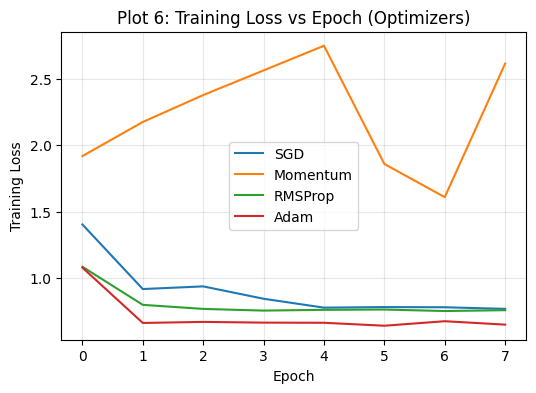

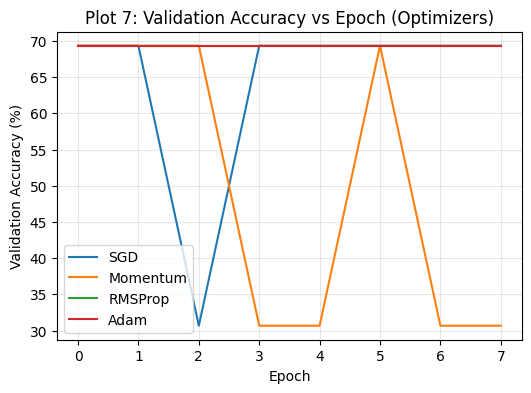


Optimizer | Final Loss | Best Val Acc (%) | Epoch to Converge | Time (s)
['SGD', 0.7707512378692627, 69.33333277702332, 1, 133.2]
['Momentum', 2.6145358085632324, 69.33333277702332, 1, 115.0]
['RMSProp', 0.7608242034912109, 69.33333277702332, 1, 119.3]
['Adam', 0.6522596478462219, 69.33333277702332, 1, 133.1]


In [3]:
optimizer_configs = {
    "SGD": lambda: optimizers.SGD(learning_rate=0.01),
    "Momentum": lambda: optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "RMSProp": lambda: optimizers.RMSprop(learning_rate=0.001),
    "Adam": lambda: optimizers.Adam(learning_rate=0.001),
}
EPOCHS = 8
opt_history, opt_summary = {}, []

for name, opt_fn in optimizer_configs.items():
    print(f"Training with {name}")
    tf.keras.backend.clear_session()
    _, model = build_model(tf.keras.initializers.HeNormal(), IMG_SIZE_SMALL, use_bn=True)
    model.compile(optimizer=opt_fn(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    hist = model.fit(train_ds_s, validation_data=val_ds_s, epochs=EPOCHS, verbose=1).history
    elapsed = time.time() - t0
    opt_history[name] = hist
    best_acc = max(hist["val_accuracy"]) * 100
    converge_epoch = int(np.argmax(hist["val_accuracy"]) + 1)
    opt_summary.append([name, hist["loss"][-1], best_acc, converge_epoch, round(elapsed, 1)])
    free_memory(model)

plt.figure(figsize=(6, 4))
for name, h in opt_history.items():
    plt.plot(h["loss"], label=name)
plt.xlabel("Epoch"); plt.ylabel("Training Loss")
plt.title("Plot 6: Training Loss vs Epoch (Optimizers)")
plt.legend(); plt.grid(alpha=0.3); plt.show(); plt.close('all')

plt.figure(figsize=(6, 4))
for name, h in opt_history.items():
    plt.plot([a * 100 for a in h["val_accuracy"]], label=name)
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 7: Validation Accuracy vs Epoch (Optimizers)")
plt.legend(); plt.grid(alpha=0.3); plt.show(); plt.close('all')

print("\nOptimizer | Final Loss | Best Val Acc (%) | Epoch to Converge | Time (s)")
for row in opt_summary:
    print(row)

Task 5

LR=0.001: best val acc = 69.33%
LR=0.0001: best val acc = 69.33%


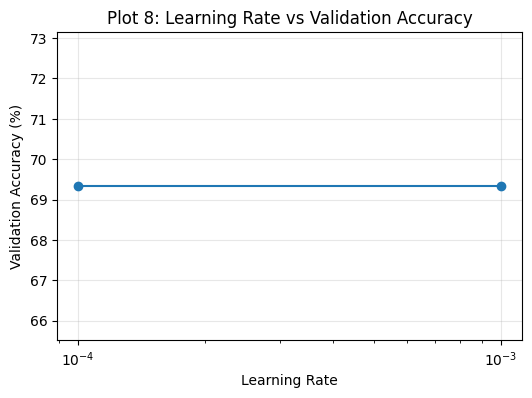

Batch size=16: best val acc = 69.33%
Batch size=32: best val acc = 69.33%
Batch size=64: best val acc = 69.33%


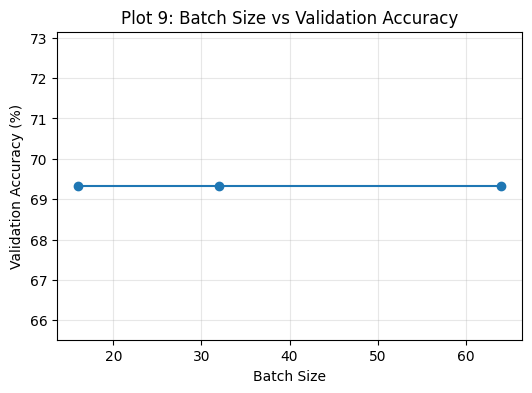

Dropout=0.0: best val acc = 69.33%
Dropout=0.25: best val acc = 69.33%
Dropout=0.5: best val acc = 69.33%


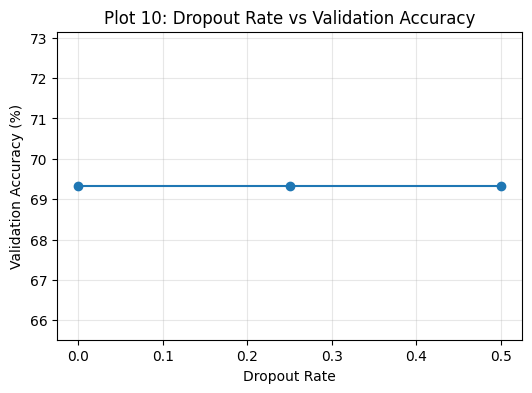

In [4]:
BASE_LR, BASE_DROPOUT = 0.001, 0.25
EPOCHS = 6

lr_results = {}
for lr in [0.001, 0.0001]:
    tf.keras.backend.clear_session()
    _, model = build_model(tf.keras.initializers.HeNormal(), IMG_SIZE_SMALL, dropout=BASE_DROPOUT, use_bn=True)
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = model.fit(train_ds_s, validation_data=val_ds_s, epochs=EPOCHS, verbose=0).history
    lr_results[lr] = max(hist["val_accuracy"]) * 100
    print(f"LR={lr}: best val acc = {lr_results[lr]:.2f}%")
    free_memory(model)

plt.figure(figsize=(6, 4))
plt.plot(list(lr_results.keys()), list(lr_results.values()), "o-")
plt.xscale("log")
plt.xlabel("Learning Rate"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 8: Learning Rate vs Validation Accuracy")
plt.grid(alpha=0.3); plt.show(); plt.close('all')

bs_results = {}
for bs in [16, 32, 64]:
    tds = make_pipeline(ds_train.take(TRAIN_SUBSET), IMG_SIZE_SMALL, shuffle=True, augment=True, batch_size=bs)
    vds = make_pipeline(ds_val.take(VAL_SUBSET), IMG_SIZE_SMALL, batch_size=bs)
    tf.keras.backend.clear_session()
    _, model = build_model(tf.keras.initializers.HeNormal(), IMG_SIZE_SMALL, dropout=BASE_DROPOUT, use_bn=True)
    model.compile(optimizer=optimizers.Adam(learning_rate=BASE_LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = model.fit(tds, validation_data=vds, epochs=EPOCHS, verbose=0).history
    bs_results[bs] = max(hist["val_accuracy"]) * 100
    print(f"Batch size={bs}: best val acc = {bs_results[bs]:.2f}%")
    free_memory(model, tds, vds)

plt.figure(figsize=(6, 4))
plt.plot(list(bs_results.keys()), list(bs_results.values()), "o-")
plt.xlabel("Batch Size"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 9: Batch Size vs Validation Accuracy")
plt.grid(alpha=0.3); plt.show(); plt.close('all')

dropout_results = {}
for dr in [0.0, 0.25, 0.5]:
    tf.keras.backend.clear_session()
    _, model = build_model(tf.keras.initializers.HeNormal(), IMG_SIZE_SMALL, dropout=dr, use_bn=True)
    model.compile(optimizer=optimizers.Adam(learning_rate=BASE_LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = model.fit(train_ds_s, validation_data=val_ds_s, epochs=EPOCHS, verbose=0).history
    dropout_results[dr] = max(hist["val_accuracy"]) * 100
    print(f"Dropout={dr}: best val acc = {dropout_results[dr]:.2f}%")
    free_memory(model)

plt.figure(figsize=(6, 4))
plt.plot(list(dropout_results.keys()), list(dropout_results.values()), "o-")
plt.xlabel("Dropout Rate"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 10: Dropout Rate vs Validation Accuracy")
plt.grid(alpha=0.3); plt.show(); plt.close('all')